# Import packages needed for running code

In [3]:
import numpy as np
from math import sqrt
import matplotlib.pyplot as plt
from scipy.stats import poisson
import pandas as pd
import random as rd
import itertools as it

# Define model's parameters

In [4]:
M = 5  # max. shelf life
mu = 3  # mean demand of Poisson distribution
Dmx = 3 * mu  # trunacte demand ceiling; you cannot realistically sell more
prob = pmf_values = poisson.pmf(np.arange(0, Dmx + 1), mu)
prob[Dmx] = 1 - prob[0:Dmx].sum()

z = 1 / sqrt(mu)  # for 1 day of safety stock set z = 1/sqrt(2)

# Dmx is the practical upperbound and 2 * mu + z * sqrt(2) * mu
# is a statistical motivated amount. Choose the lowest as the maximum
# number of items on the shelf per item age.
UBI = min(Dmx, 2 * mu + z * sqrt(2) * mu)  # Upperbound on \# items in each age class

r = 250  # regular sales price (excl. discount)
c = 175  # purchase price

Tw = 10  # warmin up period of simulation (is excluded in calculating statistics)
T = Tw + 36500  # length of a simulation (episode length).

# Reserve memory for variables

In [148]:
# (this prevents high RAM use until Garbage collection)
I = np.empty([T + 1, M], dtype=int)
IL = np.empty([T, M], dtype=int)
BSPlvl = np.empty(T, dtype=int)
Order = np.empty(T, dtype=int)
D = np.empty(T, dtype=int)
DF = np.empty(T, dtype=int)
DL = np.empty(T, dtype=int)
DeltaF = np.empty([T, M], dtype=int)
DeltaL = np.empty([T, M], dtype=int)
SALES = np.empty(T, dtype=int)
PRF = np.empty(T)
LS = np.empty(T, dtype=int)
WST = np.empty(T, dtype=int)
Profit = np.zeros(11)

# Optional functions to make states into string

In [6]:
def State2Index(I):
    idx = I[0]
    for i in range(1, M):
        idx = (1 + UBI) * idx + I[i]
    return idx


def Index2State(idx):
    Ilist = []
    for i in range(M):
        idx1 = int(idx / (1 + UBI))
        Ilist.append(idx - idx1 * (1 + UBI))
        print(idx, idx1, Ilist)
        idx = idx1
    return np.array(Ilist.reverse())

# Define state space, probabilities, action space and reward space

In [126]:
BSPlvl_temp = round(2 * mu + z * sqrt(2) * mu)
S = np.arange(BSPlvl_temp + 1)
SS = np.array(list(it.product(S, repeat = 5)))

valid = SS.sum(axis=1) <= BSPlvl_temp
SS = SS[valid]
nS = len(SS)

AA = np.arange(11)
nA = len(AA)

P = prob
RR = np.zeros([nA, nS])
PP = np.zeros([nA, nS, nS]) # Changed nS1 to nS for the third dimension

# Run the model for each action.

<ol>
  <li>Action: a discount on the oldest product.</li>
  <li>Reward: LEFO + FEFO - order costs</li>
  <li>State: combination of number of items per product age per day</li>
  <li>Probability: poisson model distribution around mu = 3</li>
</ol>





In [127]:
for aa in range(11):  #LOOP OVER DISCOUNT PERCENTAGES
    # RE-INITIALIZE variables and rand seeds
    rd.seed(42)
    np.random.seed(42)
    I[:] = np.zeros([T + 1, M], dtype=int)
    IL[:] = np.zeros([T, M], dtype=int)
    BSPlvl[:] = np.zeros(T, dtype=int)
    Order[:] = np.zeros(T, dtype=int)
    D[:] = np.zeros(T, dtype=int)
    DF[:] = np.zeros(T, dtype=int)
    DL[:] = np.zeros(T, dtype=int)
    DeltaF[:] = np.zeros([T, M], dtype=int)
    DeltaL[:] = np.zeros([T, M], dtype=int)
    SALES[:] = np.zeros(T, dtype=int)
    PRF[:] = np.zeros(T)
    LS[:] = np.zeros(T, dtype=int)
    WST[:] = np.zeros(T, dtype=int)

    I_old = np.zeros(M)
    I_new = np.zeros(M)

    # SIMULATE INVENTORY DYANMICS OVER ALL PERIODS
    for t in range(T):
        # observe state
        I_old = I[t]

        # predict demand and set BSP level
        BSPlvl[t] = round(2 * mu + z * sqrt(2) * mu)
        # set discount
        a = 0.05 * aa
        # set order quantity:
        Order[t] = max(0, BSPlvl[t] - I[t].sum())
        # set demand:
        D[t] = min(Dmx, np.random.poisson(mu))
        # split demand
        DF_frac = min(I[t, M - 1], a * D[t])
        DF_int = int(DF_frac)
        DF[t] = DF_int
        if DF_frac != DF_int:  # stochastic rounding
            Frac = DF_frac - DF_int
            u = rd.random()
            if u < Frac:
                DF[t] = DF_int + 1
        DL[t] = D[t] - DF[t]

        # pick FEFO demand:
        DeltaF[t, M - 1] = DF[t]  # only oldest are discounted (<= max I[t,M-1])
        # available for LEFO customers/adjust stock levels:
        IL[t] = I[t] - DeltaF[t]
        # pick LEFO demand:
        DeltaL[t, 0] = min(DL[t], IL[t, 0])  # youngest first
        for i in range(1, M):
            DeltaL[t, i] = min(DL[t] - DeltaL[t, 0:i].sum(), IL[t, i])

            # adjust stock levels:
        I[t + 1, :] = IL[t] - DeltaL[t]
        WST[t] = I[t + 1, M - 1]
        I[t + 1, :] = np.roll(I[t + 1], 1)
        I[t + 1, 0] = Order[t]  # as lead time is one period
        # more stats:
        LS[t] = max(0, D[t] - I[t].sum())
        SALES[t] = DeltaF[t].sum() + DeltaF[t].sum()
        PRF[t] = r * DeltaL[t].sum() + r * (1 - a) * DeltaF[t].sum() - c * Order[t]


        I_new = I[t + 1]
        ss = np.where((SS == I_old).all(axis = 1))[0][0].item()
        sss = np.where((SS == I_new).all(axis = 1))[0][0].item()

        RR[aa, ss] = PRF[t]
        PP[aa, ss, sss] += 1


    # COMPUTE & PRINT AVERAGES OF KEY PERFORMANCE MEASURES
    for i in range(nS):
        tot_s = PP[aa,i,:].sum()
        if tot_s != 0:
            PP[aa,i,:] = PP[aa,i,:] / PP[aa,i,:].sum()

    WasteRel = WST[Tw:T].mean() / Order[Tw:T].mean()
    Fillrate = 1 - LS[Tw:T].mean() / D[Tw:T].mean()
    Profit[aa] = PRF[Tw:T].mean()
    print(
        f"Discount = {a * 100:.0f}%, Profit = {Profit[aa]:.3f}, Waste = {WasteRel * 100:.1f} %, Fillrate = {Fillrate * 100:.1f} %")

Discount = 0%, Profit = 170.829, Waste = 6.8 %, Fillrate = 91.6 %
Discount = 5%, Profit = 172.349, Waste = 6.5 %, Fillrate = 91.7 %
Discount = 10%, Profit = 173.429, Waste = 6.1 %, Fillrate = 91.8 %
Discount = 15%, Profit = 173.766, Waste = 5.8 %, Fillrate = 91.9 %
Discount = 20%, Profit = 173.836, Waste = 5.4 %, Fillrate = 92.0 %
Discount = 25%, Profit = 173.204, Waste = 5.0 %, Fillrate = 92.2 %
Discount = 30%, Profit = 172.189, Waste = 4.6 %, Fillrate = 92.3 %
Discount = 35%, Profit = 170.354, Waste = 4.3 %, Fillrate = 92.3 %
Discount = 40%, Profit = 168.316, Waste = 4.0 %, Fillrate = 92.4 %
Discount = 45%, Profit = 165.949, Waste = 3.6 %, Fillrate = 92.5 %
Discount = 50%, Profit = 163.176, Waste = 3.4 %, Fillrate = 92.5 %


# Check how many states per action are possible

In [128]:
def check_states(PP, nA):
    print(f"Total number of states (second dimension): {PP.shape[1]}")
    for i in range(nA):
        count = 0
        for j in range(PP.shape[1]):  # use PP.shape[1] instead of nS to adapt dynamically
            if PP[i, j, :].sum() == 1.0:
                count += 1
        print(f'Action {i} has {count} possible states.')


In [129]:
# before removal
print("Before removal: \n")
check_states(PP, nA)

Before removal: 

Total number of states (second dimension): 1287
Action 0 has 789 possible states.
Action 1 has 788 possible states.
Action 2 has 789 possible states.
Action 3 has 794 possible states.
Action 4 has 781 possible states.
Action 5 has 784 possible states.
Action 6 has 785 possible states.
Action 7 has 778 possible states.
Action 8 has 788 possible states.
Action 9 has 801 possible states.
Action 10 has 800 possible states.


Remove nonexisting states

In [130]:
mask = PP.sum(axis=2).sum(axis=0) == 0  # shape: (1287,) — True where sum is 0

# Delete all matching indices at once
SS_copy = SS[~mask]  # remove the same zero-entries from SS
PP_copy = np.delete(PP.copy(), np.where(mask)[0], axis=1)

In [131]:
print(f"Removed {mask.sum()} zero states\n")
print(f"SS size: {len(SS_copy)}, PP axis 1 size: {PP_copy.shape[1]}")  # should be equal

Removed 328 zero states

SS size: 959, PP axis 1 size: 959


And check the possible states again - they should not have changed

In [132]:
# after removal
print("After removal: \n")
check_states(PP_copy, nA)

After removal: 

Total number of states (second dimension): 959
Action 0 has 789 possible states.
Action 1 has 788 possible states.
Action 2 has 789 possible states.
Action 3 has 794 possible states.
Action 4 has 781 possible states.
Action 5 has 784 possible states.
Action 6 has 785 possible states.
Action 7 has 778 possible states.
Action 8 has 788 possible states.
Action 9 has 801 possible states.
Action 10 has 800 possible states.


# Use Iterative Policy Evaluation with Policy Improvement.

In [162]:
pi = np.zeros(len(SS))
V = np.zeros(len(SS))
V_prev = np.zeros(len(SS))
q = np.zeros([nA, len(SS)])
gamma = 0.9
PolicyNotStable = True
niterPI = 0

while PolicyNotStable:
    niterPI += 1

    # Iterative Policy evaluation
    niterIPE = 0
    theta = 0.0001 * (1 - gamma) / (2 * gamma)
    span = 1 + theta
    while span > theta:
        niterIPE += 1
        for ids, s in enumerate(SS):
            a = pi[ids]
            ida = np.where(AA == a)[0][0]  # look up the action index associated with action a
            V[ids] = RR[ida, ids] + gamma * PP[ida, ids, :] @ V_prev

        Diff = V - V_prev
        span = max(Diff) - min(Diff)
        V_prev = V.copy()  # create a copy of the content of V, rather than copy the reference to V
        niterIPE += 1
    print(niterPI, niterIPE, pi)

    # POLICY IMPROVEMENT
    pi_prev = pi.copy()
    PolicyNotStable = False
    for ids, s in enumerate(SS):
        qbest = - np.inf
        for ida, a in enumerate(AA):
            q[ida, ids] = RR[ida, ids] + gamma * PP[ida, ids, :] @ V_prev
            if q[ida, ids] > qbest:
                pi[ids] = a
                qbest = q[ida, ids]
        if pi[ids] != pi_prev[ids]:
            PolicyNotStable = True




1 334 [0. 0. 0. ... 0. 0. 0.]
2 330 [0. 0. 0. ... 0. 4. 7.]
3 270 [0. 0. 0. ... 0. 0. 1.]
4 192 [0. 0. 0. ... 0. 0. 1.]


# Look into the contents of the final policy

In [163]:
val_d = {}
for i in pi:
    if i in val_d:
        val_d[i] += 1
    else:
        val_d[i] = 1

In [164]:
for key in val_d:
    print(f'{key} : {val_d[key]}')

0.0 : 492
3.0 : 83
6.0 : 84
1.0 : 57
7.0 : 78
5.0 : 66
2.0 : 76
10.0 : 77
4.0 : 100
8.0 : 85
9.0 : 89


# Plot out the baseline figure

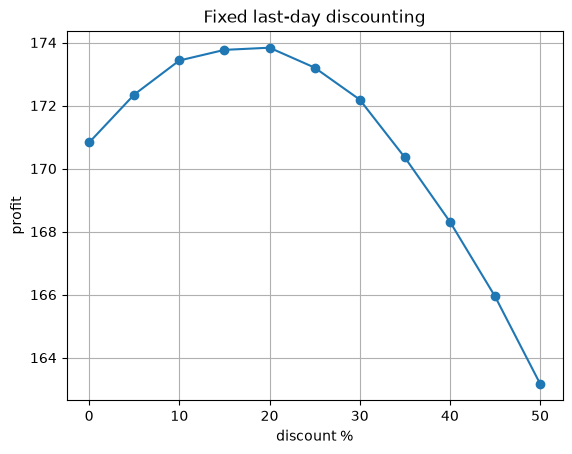

                 I  BSPlvl  Order  D            Delta  LS  Wst     Prf
0  [0, 0, 0, 0, 0]       8      8  4  [0, 0, 0, 0, 0]   4    0 -1400.0
1  [8, 0, 0, 0, 0]       8      0  1  [0, 0, 0, 0, 0]   0    0   250.0
2  [0, 7, 0, 0, 0]       8      1  3  [0, 0, 0, 0, 0]   0    0   575.0
3  [1, 0, 4, 0, 0]       8      3  3  [0, 0, 0, 0, 0]   0    0   225.0
4  [3, 0, 0, 2, 0]       8      3  2  [0, 0, 0, 0, 0]   0    0   -25.0
5  [3, 1, 0, 0, 2]       8      2  3  [0, 0, 0, 0, 2]   0    1   275.0
6  [2, 1, 1, 0, 0]       8      4  2  [0, 0, 0, 0, 0]   0    0  -200.0
7  [4, 0, 1, 1, 0]       8      2  3  [0, 0, 0, 0, 0]   0    0   400.0
8  [2, 1, 0, 1, 1]       8      3  0  [0, 0, 0, 0, 0]   0    1  -525.0
9  [3, 2, 1, 0, 1]       8      1  2  [0, 0, 0, 0, 2]   0    0   200.0
                     I  BSPlvl  Order  D            Delta  LS  Wst    Prf
36500  [6, 1, 0, 0, 0]       8      1  2  [0, 0, 0, 0, 0]   0    0  325.0
36501  [1, 4, 1, 0, 0]       8      2  0  [0, 0, 0, 0, 0]   0    0 -350

In [81]:
plt.plot(5 * np.arange(11), Profit, marker='o')  # Line plot with points
plt.title("Fixed last-day discounting")
plt.xlabel("discount %")
plt.ylabel("profit")
plt.grid(True)
plt.show()

# plt.plot(D)
# plt.show()
# plt.plot(LS)
# plt.show()

df = pd.DataFrame(
    {'I': list(I[0:T]) ,
     'BSPlvl': BSPlvl,
     'Order': Order,
     'D': D,
     'Delta': list(DeltaF + DeltaF),
     'LS': LS,
     'Wst': WST,
     'Prf': PRF
     })

print(df.head(10))
print(df.tail(10))


# Run the policy on the model

In [168]:
rd.seed(42)
np.random.seed(42)
I[:] = np.zeros([T + 1, M], dtype=int)
IL[:] = np.zeros([T, M], dtype=int)
BSPlvl[:] = np.zeros(T, dtype=int)
Order[:] = np.zeros(T, dtype=int)
D[:] = np.zeros(T, dtype=int)
DF[:] = np.zeros(T, dtype=int)
DL[:] = np.zeros(T, dtype=int)
DeltaF[:] = np.zeros([T, M], dtype=int)
DeltaL[:] = np.zeros([T, M], dtype=int)
SALES[:] = np.zeros(T, dtype=int)
PRF[:] = np.zeros(T, dtype = int)
LS[:] = np.zeros(T, dtype=int)
WST[:] = np.zeros(T, dtype=int)

# SIMULATE INVENTORY DYANMICS OVER ALL PERIODS
for t in range(T):

    # predict demand and set BSP level
    BSPlvl[t] = round(2 * mu + z * sqrt(2) * mu)

    # set discount
    pi_a_idx = np.where((SS == I[t]).all(axis = 1))[0][0].item()
    a = 0.05 * pi[pi_a_idx]

    # set order quantity:
    Order[t] = max(0, BSPlvl[t] - I[t].sum())

    # set demand:
    D[t] = min(Dmx, np.random.poisson(mu))

    # split demand
    DF_frac = min(I[t, M - 1], a * D[t])
    DF_int = int(DF_frac)
    DF[t] = DF_int
    if DF_frac != DF_int:  # stochastic rounding
        Frac = DF_frac - DF_int
        u = rd.random()
        if u < Frac:
            DF[t] = DF_int + 1
    DL[t] = D[t] - DF[t]

    # pick FEFO demand:
    DeltaF[t, M - 1] = DF[t]  # only oldest are discounted (<= max I[t,M-1])

    # available for LEFO customers/adjust stock levels:
    IL[t] = I[t] - DeltaF[t]

    # pick LEFO demand:
    DeltaL[t, 0] = min(DL[t], IL[t, 0])  # youngest first
    for i in range(1, M):
        DeltaL[t, i] = min(DL[t] - DeltaL[t, 0:i].sum(), IL[t, i])

    # adjust stock levels:
    I[t + 1, :] = IL[t] - DeltaL[t]
    WST[t] = I[t + 1, M - 1]
    I[t + 1, :] = np.roll(I[t + 1], 1)
    I[t + 1, 0] = Order[t]  # as lead time is one period

    # more stats:
    LS[t] = max(0, D[t] - I[t].sum())
    SALES[t] = DeltaF[t].sum() + DeltaF[t].sum()
    PRF[t] = r * DeltaL[t].sum() + r * (1 - a) * DeltaF[t].sum() - c * Order[t]

WasteRel = WST[Tw:T].mean() / Order[Tw:T].mean()
Fillrate = 1 - LS[Tw:T].mean() / D[Tw:T].mean()
Profit = PRF[Tw:T].mean()
print(f"Profit = {Profit:.3f}, Waste = {WasteRel * 100:.1f} %, Fillrate = {Fillrate * 100:.1f} %")

Profit = 171.969, Waste = 4.9 %, Fillrate = 92.2 %
